# Preliminary Solver Performance Analysis for 0-1 Knapsack Problems

This notebook provides preliminary analysis of the implemented solver portfolio.

The current experiment compares:

- Greedy heuristic algorithm
- Dynamic programming exact algorithm

Evaluation metrics:

- Solution quality
- Optimality gap
- Computational runtime

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

import os

In [25]:
df = pd.read_csv("../results/solver_results.csv")
df.head()

,id,correlation,n_items,capacity,greedy_profit,dp_profit,gap,greedy_time,dp_time
0,0,uncorrelated,50,1324,1778,1778,0.000000,0.000182,0.041364
1,1,weak,50,1108,2039,2053,0.006819,0.000081,0.035864
2,2,strong,50,1366,3112,3125,0.004160,0.000108,0.043063
3,3,uncorrelated,50,1120,2028,2041,0.006369,0.000079,0.035503
4,4,weak,50,1238,2206,2209,0.001358,0.000079,0.040835


## Dataset Overview

In [26]:
df.describe()

,id,n_items,capacity,greedy_profit,dp_profit,gap,greedy_time,dp_time
count,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,49.500000,50.0,1240.140000,2357.270000,2368.190000,0.004436,0.000082,0.040370
std,29.011492,0.0,101.135674,397.383382,401.469188,0.004701,0.000019,0.003747
min,0.000000,50.0,987.000000,1692.000000,1692.000000,0.000000,0.000061,0.031256
25%,24.750000,50.0,1185.250000,2070.500000,2074.250000,0.000436,0.000072,0.038286
50%,49.500000,50.0,1247.000000,2221.500000,2231.500000,0.002511,0.000075,0.040618
75%,74.250000,50.0,1295.750000,2692.500000,2729.000000,0.006888,0.000082,0.042642
max,99.000000,50.0,1526.000000,3119.000000,3131.000000,0.018975,0.000183,0.053961


## Solution Quality Comparison

Dynamic programming provides optimal solutions,
while greedy provides faster approximate solutions.

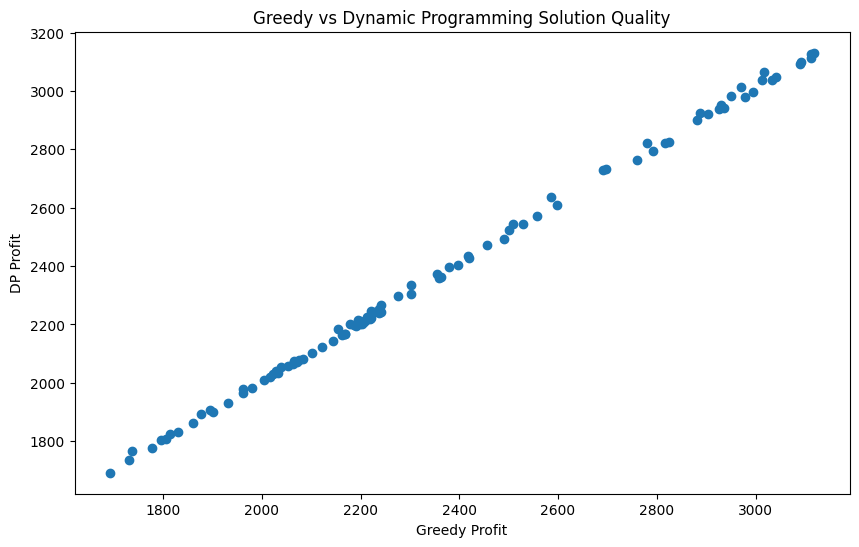

In [27]:
plt.figure(figsize=(10, 6))

plt.scatter(df["greedy_profit"], df["dp_profit"])

plt.xlabel("Greedy Profit")
plt.ylabel("DP Profit")
plt.title("Greedy vs Dynamic Programming Solution Quality")

plt.show()

## Optimality Gap Analysis

The optimality gap measures how close the greedy solution is compared with the exact solution.

\[
Gap=
\frac{P_{DP}-P_{Greedy}}
{P_{DP}}
\]

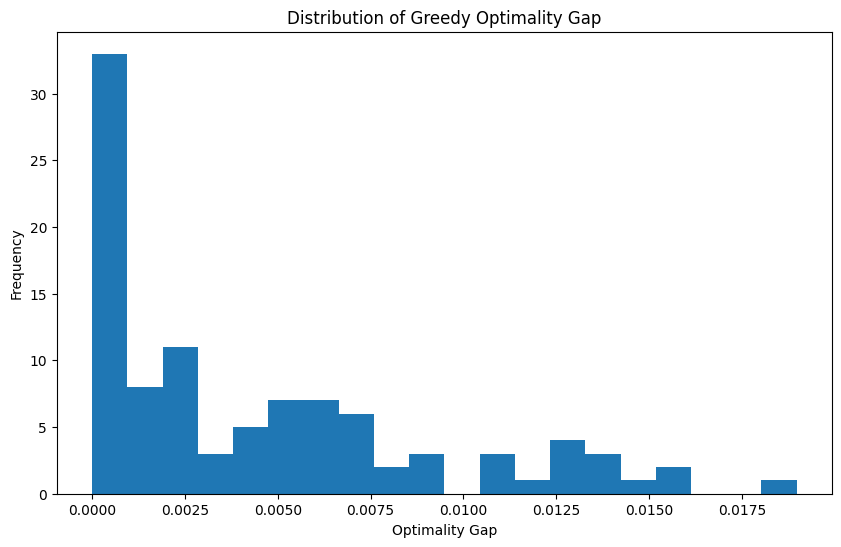

In [28]:
plt.figure(figsize=(10, 6))

plt.hist(df["gap"], bins=20)

plt.xlabel("Optimality Gap")
plt.ylabel("Frequency")
plt.title("Distribution of Greedy Optimality Gap")

plt.show()

## Computational Runtime Comparison

Greedy achieves significantly lower computational cost,
while dynamic programming provides exact solutions.

In [29]:
runtime_df = df[["greedy_time", "dp_time"]]

runtime_df.mean()

greedy_time    0.000082
dp_time        0.040370
dtype: float64

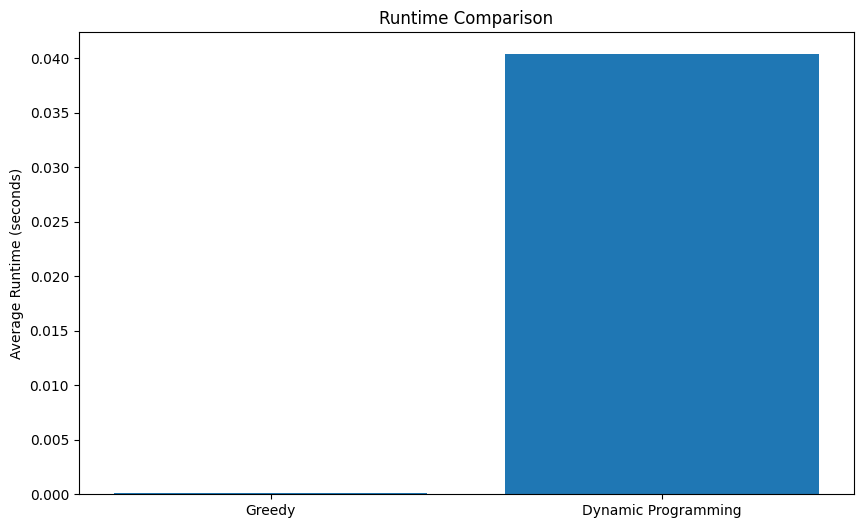

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(["Greedy", "Dynamic Programming"], [df["greedy_time"].mean(), df["dp_time"].mean()])

plt.ylabel("Average Runtime (seconds)")
plt.title("Runtime Comparison")

plt.show()

## Current Limitation and Future Improvement

The current benchmark provides an initial validation of the solver evaluation framework. However, the generated instances currently exhibit limited diversity, resulting in an imbalanced solver preference distribution.

Future experiments will improve benchmark diversity by introducing:

- varying problem sizes,
- different capacity ratios,
- additional correlation structures.

This will provide a more challenging environment for evaluating learning-based algorithm selection.

## Preliminary Findings

The preliminary experiments show:

1. Dynamic programming consistently achieves optimal solutions.

2. Greedy provides competitive solution quality with significantly lower runtime.

3. Solver performance varies across different problem instances.

These observations motivate the development of learning-based algorithm selection methods.